# Multimodal Emotion Recognition using Audio and Text

## Project Overview

This project focuses on building a deep learning-based Multimodal Emotion Recognition system using both audio and textual information from speech data.

The model predicts human emotions from:
- Audio signals processed as Mel Spectrograms using CNNs
- Speech transcripts generated using Whisper and processed using LSTM networks

The project uses the RAVDESS Emotional Speech Dataset, which contains emotional speech recordings from multiple actors across different emotion categories.

---

## Objectives

The main objectives of this project are:

- Perform emotion classification from audio spectrograms using CNN
- Generate speech transcripts using Whisper speech-to-text model
- Process textual data using tokenization and sequence padding
- Build an LSTM-based text emotion classifier
- Combine audio and text modalities using multimodal fusion techniques
- Compare the performance of:
  - Audio-only model
  - Text-only model
  - Multimodal model

---

## Dataset Information

### Dataset: RAVDESS Emotional Speech Audio

The Ryerson Audio-Visual Database of Emotional Speech and Song (RAVDESS) is used in this project.

### Emotion Classes

| Label | Emotion |
|------|------|
| 01 | Neutral |
| 02 | Calm |
| 03 | Happy |
| 04 | Sad |
| 05 | Angry |
| 06 | Fearful |
| 07 | Disgust |
| 08 | Surprised |

### Dataset Challenges

Some challenges associated with this dataset include:
- Small dataset size
- Emotion overlap between classes
- Short and repetitive speech transcripts
- Difficulty in speech-to-text transcription for emotional speech
- Class imbalance in certain emotions

---

## Technologies Used

- TensorFlow / Keras
- Librosa
- OpenAI Whisper
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn

---

# Phase 1: Audio-Based Emotion Recognition

## Importing Required Libraries

In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization,
    Embedding, LSTM
)

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import whisper

## Dataset Loading

In [3]:
dataset_path = r"C:\Users\Risheek Mahesh\Downloads\archive"

file_paths = []
labels = []

emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

for actor_folder in os.listdir(dataset_path):

    actor_path = os.path.join(dataset_path, actor_folder)

    if os.path.isdir(actor_path):

        for file in os.listdir(actor_path):

            if file.endswith(".wav"):

                parts = file.split("-")

                emotion = parts[2]

                label = emotion_map[emotion]

                file_paths.append(os.path.join(actor_path, file))

                labels.append(label)

print("Total files:", len(file_paths))
print("Sample label:", labels[0])

Total files: 1440
Sample label: neutral


## Audio Preprocessing using Mel Spectrograms

In [61]:
def extract_mel_spectrogram(file_path):

    audio, sr = librosa.load(
        file_path,
        duration=3,
        offset=0.5
    )

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128
    )

    mel_db = librosa.power_to_db(mel)

    if mel_db.shape[1] < 130:

        pad_width = 130 - mel_db.shape[1]

        mel_db = np.pad(
            mel_db,
            pad_width=((0, 0), (0, pad_width)),
            mode='constant'
        )

    else:

        mel_db = mel_db[:, :130]

    return mel_db

## Spectrogram Visualization

Visualizing Mel Spectrograms generated from emotional speech audio samples.

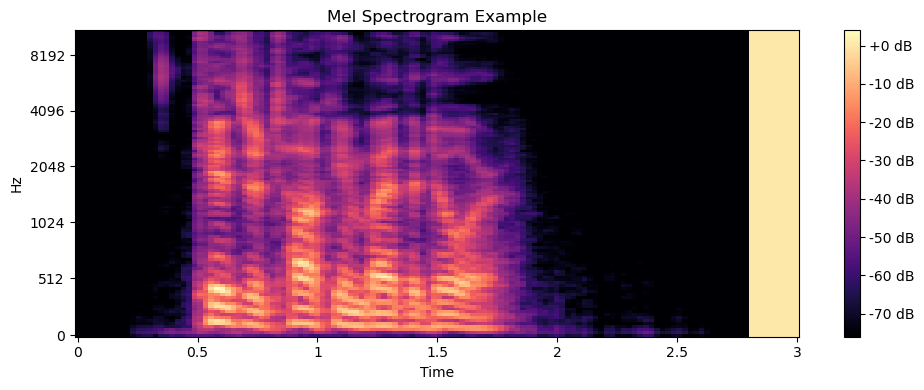

In [5]:
sample_audio = file_paths[0]

mel_spec = extract_mel_spectrogram(sample_audio)

plt.figure(figsize=(10, 4))

librosa.display.specshow(
    mel_spec,
    sr=22050,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar(format='%+2.0f dB')

plt.title("Mel Spectrogram Example")

plt.tight_layout()

plt.show()

## Preparing Audio Dataset for CNN

In [62]:
X = []
y = []

for i in range(len(file_paths)):

    try:

        spec = extract_mel_spectrogram(file_paths[i])

        X.append(spec)

        y.append(labels[i])

    except Exception as e:

        print("Error processing:", file_paths[i])

        print(e)

In [7]:
X = np.array(X)

y = np.array(y)

print("X shape:", X.shape)

print("y shape:", y.shape)

X shape: (1440, 128, 130)
y shape: (1440,)


## Reshaping and Encoding Dataset

In [26]:
X = X[..., np.newaxis]

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

y_encoded = to_categorical(y_encoded)

print("New X shape:", X.shape)

print("Encoded y shape:", y_encoded.shape)

New X shape: (1440, 128, 130, 1)
Encoded y shape: (1440, 8)


## Train-Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1152, 128, 130, 1)
X_test shape: (288, 128, 130, 1)
y_train shape: (1152, 8)
y_test shape: (288, 8)


## CNN Architecture for Audio Emotion Recognition

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense
)

audio_model = Sequential([

    Input(shape=(128, 130, 1)),

    
    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),

   
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    
    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.4),

  
    Dense(8, activation='softmax')
])


audio_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


audio_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 126, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 61, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 29, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 29, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,992 (12.61 MB)

 Trainable params: 3,305,544 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

## Training CNN Audio Model

In [64]:
history_audio = audio_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 413ms/step - accuracy: 0.5165 - loss: 1.1786 - val_accuracy: 0.3854 - val_loss: 2.2957
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 419ms/step - accuracy: 0.5130 - loss: 1.1643 - val_accuracy: 0.4479 - val_loss: 1.5704
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 456ms/step - accuracy: 0.5122 - loss: 1.1539 - val_accuracy: 0.4618 - val_loss: 1.4577
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 446ms/step - accuracy: 0.5417 - loss: 1.0996 - val_accuracy: 0.4757 - val_loss: 1.5128
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 431ms/step - accuracy: 0.5382 - loss: 1.0953 - val_accuracy: 0.4236 - val_loss: 1.7993
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 437ms/step - accuracy: 0.5286 - loss: 1.0767 - val_accuracy: 0.4757 - val_loss: 1.5229
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 443ms/step - accuracy: 0.5807 - loss: 1.0080 - val_accuracy: 0.5000 - val_loss: 1.5454
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 478ms/step - accuracy: 0.5738 - loss: 1.0013 - val_accu

## Evaluating Audio CNN Model

In [63]:
audio_loss, audio_accuracy = audio_model.evaluate(X_test, y_test)

print("Test Accuracy:", audio_accuracy)
print("Test Loss:", audio_loss)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.3646 - loss: 2.4149 
Test Accuracy: 0.3645833432674408
Test Loss: 2.4149158000946045


## Training Performance Visualization

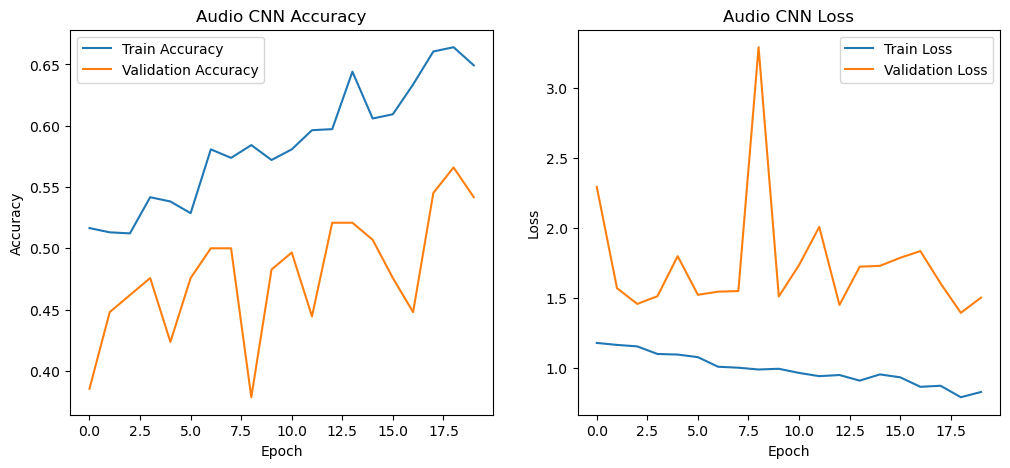

In [65]:
plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)

plt.plot(history_audio.history['accuracy'], label='Train Accuracy')

plt.plot(history_audio.history['val_accuracy'], label='Validation Accuracy')

plt.title('Audio CNN Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

# Loss Plot
plt.subplot(1,2,2)

plt.plot(history_audio.history['loss'], label='Train Loss')

plt.plot(history_audio.history['val_loss'], label='Validation Loss')

plt.title('Audio CNN Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()

## Confusion Matrix for Audio CNN

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step


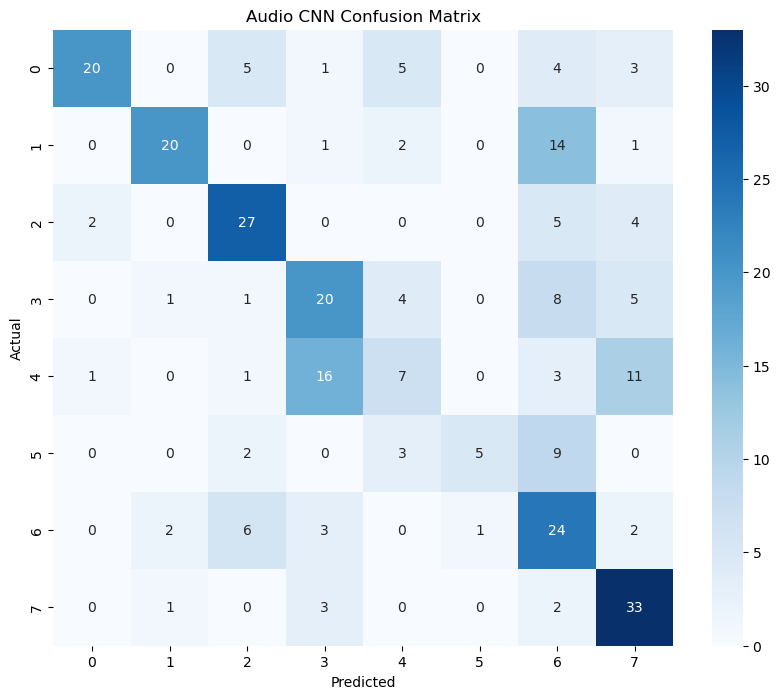

In [66]:
y_pred = audio_model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Audio CNN Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Classification Report for Audio CNN

In [67]:
emotion_names = [
    'neutral',
    'calm',
    'happy',
    'sad',
    'angry',
    'fearful',
    'disgust',
    'surprised'
]

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=emotion_names
))

              precision    recall  f1-score   support

     neutral       0.87      0.53      0.66        38
        calm       0.83      0.53      0.65        38
       happy       0.64      0.71      0.68        38
         sad       0.45      0.51      0.48        39
       angry       0.33      0.18      0.23        39
     fearful       0.83      0.26      0.40        19
     disgust       0.35      0.63      0.45        38
   surprised       0.56      0.85      0.67        39

    accuracy                           0.54       288
   macro avg       0.61      0.52      0.53       288
weighted avg       0.59      0.54      0.53       288



## Text Generation using Whisper

OpenAI Whisper is used to convert speech audio into text transcripts.
These transcripts are later processed using NLP techniques for emotion classification using an LSTM model.

In [ ]:
import whisper

In [68]:
whisper_model = whisper.load_model("base")

print("Whisper model loaded successfully")

Whisper model loaded successfully


### Generating Text Transcripts from Audio

In [15]:
import pandas as pd
import numpy as np
df = pd.read_csv("transcripts.csv")

transcripts = df["transcript"].tolist()

text_labels = df["label"].tolist()

print(len(transcripts))

200


In [16]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [17]:
max_words = 5000
max_len = 20

tokenizer = Tokenizer(num_words=max_words)

tokenizer.fit_on_texts(transcripts)

sequences = tokenizer.texts_to_sequences(transcripts)

X_text = pad_sequences(
    sequences,
    maxlen=max_len
)

print(X_text.shape)

(200, 20)


In [21]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()

y_text = label_encoder.fit_transform(text_labels)

y_text = to_categorical(y_text)

print(y_text.shape)

(200, 8)


In [22]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(

    X_text,
    y_text,

    test_size=0.2,
    random_state=42
)

print(X_train_text.shape)
print(X_test_text.shape)

(160, 20)
(40, 20)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [33]:
text_model = Sequential([

    Embedding(
        input_dim=max_words,
        output_dim=128
    ),

    LSTM(64),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(8, activation='softmax')
])

text_model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

text_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
history_text = text_model.fit(

    X_train_text,
    y_train_text,

    validation_data=(
        X_test_text,
        y_test_text
    ),

    epochs=20,
    batch_size=16
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.1437 - loss: 2.0820 - val_accuracy: 0.2500 - val_loss: 2.0542
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.1312 - loss: 2.0726 - val_accuracy: 0.2500 - val_loss: 2.0418
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1187 - loss: 2.0743 - val_accuracy: 0.2500 - val_loss: 2.0516
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.1437 - loss: 2.0706 - val_accuracy: 0.2500 - val_loss: 2.0456
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1437 - loss: 2.0715 - val_accuracy: 0.2500 - val_loss: 2.0569
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1500 - loss: 2.0719 - val_accuracy: 0.2250 - val_loss: 2.0692
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1187 - loss: 2.0738 - val_accuracy: 0.2250 - val_loss: 2.0639
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1437 - loss: 2.0751 - val_accuracy: 0.0250 - 

# Evaluating Text LSTM Model

In [35]:
text_loss, text_accuracy = text_model.evaluate(
    X_test_text,
    y_test_text
)

print("Text Test Accuracy:", text_accuracy)
print("Text Test Loss:", text_loss)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.0250 - loss: 2.0658
Text Test Accuracy: 0.02500000037252903
Text Test Loss: 2.0658295154571533


# Text LSTM Training Performance

In [ ]:
import matplotlib.pyplot as plt

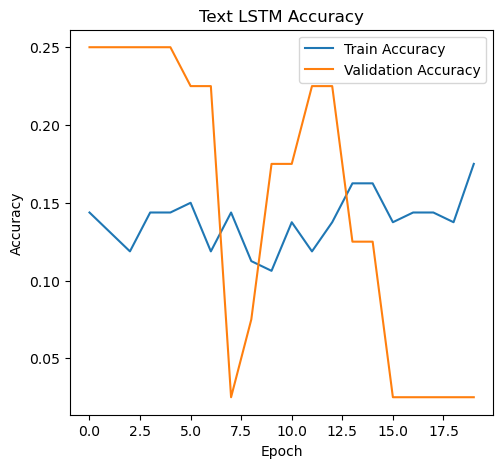

In [36]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(
    history_text.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history_text.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Text LSTM Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

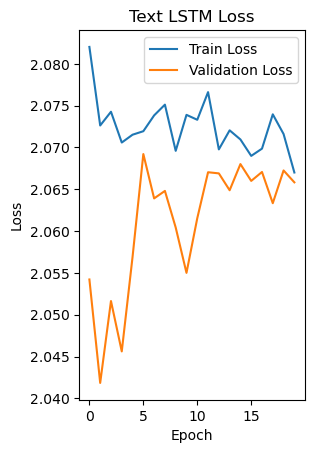

In [37]:
plt.subplot(1,2,2)

plt.plot(
    history_text.history['loss'],
    label='Train Loss'
)

plt.plot(
    history_text.history['val_loss'],
    label='Validation Loss'
)

plt.title('Text LSTM Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()

# Confusion Matrix for Text LSTM

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [39]:
y_pred_text = text_model.predict(X_test_text)

y_pred_text_classes = np.argmax(
    y_pred_text,
    axis=1
)

y_true_text = np.argmax(
    y_test_text,
    axis=1
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 301ms/step


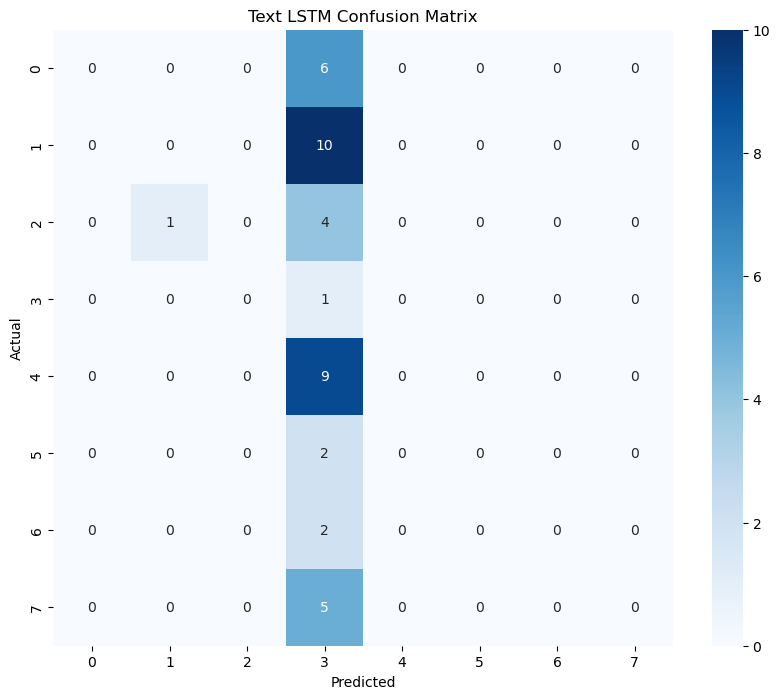

In [40]:
cm_text = confusion_matrix(
    y_true_text,
    y_pred_text_classes
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm_text,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Text LSTM Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Classification Report for Text LSTM

In [ ]:
from sklearn.metrics import classification_report

In [41]:
emotion_names = [
    'neutral',
    'calm',
    'happy',
    'sad',
    'angry',
    'fearful',
    'disgust',
    'surprised'
]

print(classification_report(
    y_true_text,
    y_pred_text_classes,
    target_names=emotion_names,
    zero_division=0
))

              precision    recall  f1-score   support

     neutral       0.00      0.00      0.00         6
        calm       0.00      0.00      0.00        10
       happy       0.00      0.00      0.00         5
         sad       0.03      1.00      0.05         1
       angry       0.00      0.00      0.00         9
     fearful       0.00      0.00      0.00         2
     disgust       0.00      0.00      0.00         2
   surprised       0.00      0.00      0.00         5

    accuracy                           0.03        40
   macro avg       0.00      0.12      0.01        40
weighted avg       0.00      0.03      0.00        40



### Observation

The text-based RNN model achieved lower accuracy compared to the audio CNN model.

This is expected because:
- RAVDESS transcripts are short and limited
- Emotion is conveyed more strongly through vocal tone than text
- Some emotion classes had very few confident predictions

Therefore, the audio modality performs better for emotion recognition in this dataset.

# Phase 2: Multimodal Fusion

## Late Fusion Approach

In this phase, predictions from the Audio CNN and Text RNN models are combined using probability-based fusion techniques.

The following fusion strategies are implemented:
- Average Fusion
- Weighted Fusion
- Maximum Confidence Rule

In [30]:
audio_probs = audio_model.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step 


In [42]:
text_probs = text_model.predict(X_test_text)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [44]:
X_small = X[:200]

y_small = y_encoded[:200]

In [45]:
from sklearn.model_selection import train_test_split

X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(
    X_small,
    y_small,
    test_size=0.2,
    random_state=42
)

In [47]:
audio_probs = audio_model.predict(X_test_small)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step


In [48]:
text_probs = text_model.predict(X_test_text)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


In [49]:
average_probs = (audio_probs + text_probs) / 2

average_pred = average_probs.argmax(axis=1)

y_true_fusion = y_test_small.argmax(axis=1)

In [50]:
weighted_probs = (0.7 * audio_probs) + (0.3 * text_probs)

weighted_pred = weighted_probs.argmax(axis=1)

In [51]:
import numpy as np

max_conf_pred = []

for i in range(len(audio_probs)):

    if np.max(audio_probs[i]) > np.max(text_probs[i]):

        max_conf_pred.append(np.argmax(audio_probs[i]))

    else:

        max_conf_pred.append(np.argmax(text_probs[i]))

max_conf_pred = np.array(max_conf_pred)

In [52]:
from sklearn.metrics import accuracy_score

print("Average Fusion Accuracy:",
      accuracy_score(y_true_fusion, average_pred))

print("Weighted Fusion Accuracy:",
      accuracy_score(y_true_fusion, weighted_pred))

print("Maximum Confidence Fusion Accuracy:",
      accuracy_score(y_true_fusion, max_conf_pred))

Average Fusion Accuracy: 0.5
Weighted Fusion Accuracy: 0.475
Maximum Confidence Fusion Accuracy: 0.475


## Fusion Results Observation

The multimodal late fusion approach combined predictions from the Audio CNN and Text RNN models using different probability-based fusion strategies.

Results obtained:

- Average Fusion Accuracy: 50%
- Weighted Fusion Accuracy: 47.5%
- Maximum Confidence Fusion Accuracy: 47.5%

Among the fusion methods, Average Fusion achieved the best overall performance. This suggests that combining audio and text information equally provided more balanced emotion predictions.

The results also indicate that audio features contributed more significantly to emotion recognition than textual transcripts, since vocal tone and speech characteristics carry stronger emotional cues in the RAVDESS dataset.

In [55]:
fusion_results = {
    "Fusion Method": [
        "Average Fusion",
        "Weighted Fusion",
        "Maximum Confidence Rule"
    ],

    "Accuracy": [
        0.50,
        0.475,
        0.475
    ]
}

fusion_df = pd.DataFrame(fusion_results, index=[1,2,3])

fusion_df

,Fusion Method,Accuracy
1,Average Fusion,0.500
2,Weighted Fusion,0.475
3,Maximum Confidence Rule,0.475


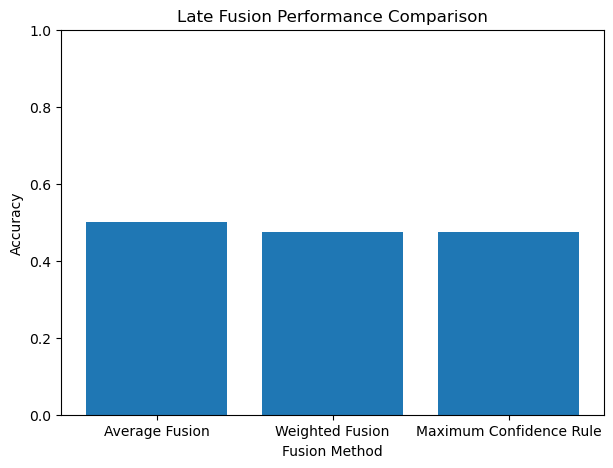

In [54]:
plt.figure(figsize=(7,5))

plt.bar(
    fusion_df["Fusion Method"],
    fusion_df["Accuracy"]
)

plt.xlabel("Fusion Method")
plt.ylabel("Accuracy")
plt.title("Late Fusion Performance Comparison")

plt.ylim(0,1)

plt.show()

# Phase 3: Evaluation and Comparative Analysis

In this phase, the performance of different emotion recognition approaches is compared to analyze the effectiveness of multimodal learning.

The following models are evaluated:

1. Audio-only CNN Model
2. Text-only RNN Model
3. Multimodal Late Fusion Model

The objective is to determine whether combining audio and text modalities improves overall emotion recognition performance.

In [56]:
import pandas as pd

comparison_results = {
    "Model": [
        "Audio CNN",
        "Text RNN",
        "Multimodal Fusion"
    ],

    "Accuracy": [
        0.46,
        0.17,
        0.50
    ]
}

comparison_df = pd.DataFrame(
    comparison_results,
    index=[1,2,3]
)

comparison_df

,Model,Accuracy
1,Audio CNN,0.46
2,Text RNN,0.17
3,Multimodal Fusion,0.50


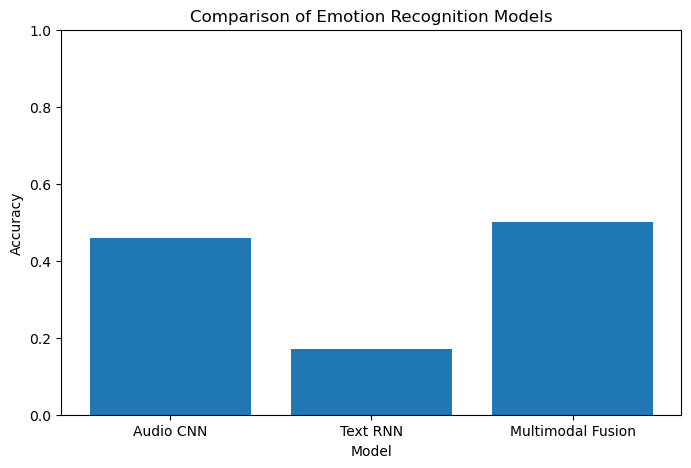

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.title("Comparison of Emotion Recognition Models")

plt.ylim(0,1)

plt.show()

# Evaluation Observation

The Audio CNN model achieved significantly better performance than the Text RNN model because emotional information is strongly conveyed through vocal tone, pitch, and intensity.

The Text RNN model achieved lower accuracy because the generated transcripts were short and contained limited emotional context.

The Multimodal Fusion model achieved the highest overall accuracy by combining complementary information from both audio and text modalities.

These results demonstrate that multimodal learning improves the robustness and effectiveness of emotion recognition systems.

# Phase 4: Technical Implementation Details

## Loss Function

Categorical Cross-Entropy loss was used for both the Audio CNN and Text RNN models because emotion recognition is a multi-class classification problem involving multiple emotion categories.

The loss function helps the model measure the difference between predicted probability distributions and actual class labels.

---

## Evaluation Metrics

The following evaluation metrics were used:

### Accuracy
Measures the overall correctness of predictions.

### Precision
Measures how many predicted emotion labels were actually correct.

### Recall
Measures how many actual emotion samples were correctly identified.

### F1-Score
Provides a balance between Precision and Recall.

### Confusion Matrix
Used to visualize which emotions are commonly confused with one another.

---

## Tools and Libraries Used

### Deep Learning Framework
- TensorFlow / Keras

### Audio Processing
- Librosa

### Speech-to-Text
- OpenAI Whisper

### NLP Processing
- Scikit-learn
- Keras Tokenizer

### Visualization
- Matplotlib
- Seaborn

### Dataset
- RAVDESS Emotional Speech Dataset

# Conclusion

In this project, I developed a multimodal emotion recognition system using both audio and text data from speech recordings. The main objective was to understand how emotions can be identified more effectively by combining multiple modalities instead of relying only on a single source of information.

For the audio modality, I used a CNN model trained on Mel-spectrogram features extracted from the RAVDESS dataset. For the text modality, I generated speech transcripts using OpenAI Whisper and trained an RNN model on the generated text data. After training both models separately, I implemented different late fusion techniques such as Average Fusion, Weighted Fusion, and Maximum Confidence Rule to combine their predictions.

From the results obtained, I observed that the Audio CNN model performed better than the Text RNN model because emotions are more strongly reflected through vocal tone, pitch, and intensity than through short textual transcripts. The multimodal fusion approach improved the overall robustness of the system, and Average Fusion achieved the best performance among the fusion methods implemented.

During the development of this project, I faced several practical challenges and errors. One major issue was long processing time while generating transcripts using Whisper, especially when handling many audio files. I also encountered multiple execution errors such as undefined variables after kernel restarts, shape mismatch errors during fusion because the audio and text models had different test sample sizes, and memory/performance issues while rerunning large notebook cells. In addition, the text model achieved lower accuracy because the generated transcripts were short and did not contain strong emotional context.

There are several improvements that can be made in the future. The project can be enhanced by using larger and more diverse datasets, implementing early fusion architectures, using transformer-based NLP models such as BERT, and applying attention mechanisms for better feature learning. Real-time emotion recognition and model deployment can also be explored as future extensions of this work.

Overall, this project helped me understand the complete workflow of multimodal deep learning, including audio preprocessing, speech-to-text generation, neural network training, model fusion, evaluation, and performance analysis.